In [86]:
import numpy as np
import pandas as pd

from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder

RANDOM_STATE = 42
TARGET_COL = 'Depression'
ID_COL = 'id'

train_path = '../data/train.csv'
test_path = '../data/test.csv'

train = pd.read_csv(train_path)
test = pd.read_csv(test_path)

In [87]:
# 1. Tách feature và target
drop_cols = [ID_COL, 'Name']

X = train.drop(columns=[TARGET_COL] + drop_cols)
y = train[TARGET_COL]
X_test = test.drop(columns=drop_cols)
test_ids = test[ID_COL]

In [88]:
#2. Chuẩn hoá categorical, xử lý missing theo vai trò và thêm missing indicator
ROLE_COL = 'Working Professional or Student'
STUDENT_ONLY_NUMERIC_COLS = ['Academic Pressure', 'CGPA', 'Study Satisfaction']
WORK_ONLY_NUMERIC_COLS = ['Work Pressure', 'Job Satisfaction']
WORK_ONLY_CATEGORICAL_COLS = ['Profession']
BINARY_YES_NO_COLS = [
    'Have you ever had suicidal thoughts ?',
    'Family History of Mental Illness',
]


def clean_string_columns(df):
    df = df.copy()
    obj_cols = df.select_dtypes(include=['object', 'string']).columns
    for col in obj_cols:
        # sklearn SimpleImputer can fail on pandas pd.NA, so keep missing as np.nan.
        df[col] = df[col].astype('object')
        df[col] = df[col].where(df[col].notna(), np.nan)
        df[col] = df[col].str.strip()
        df[col] = df[col].replace({'': np.nan, 'nan': np.nan, 'None': np.nan})
    return df


def add_missing_indicators(df, cols):
    df = df.copy()
    for col in cols:
        df[f'{col}_is_missing'] = df[col].isna().astype(int)
    return df


def fill_structural_missing_by_role(df):
    df = df.copy()
    is_student = df[ROLE_COL].eq('Student')
    is_professional = df[ROLE_COL].eq('Working Professional')

    for col in STUDENT_ONLY_NUMERIC_COLS:
        if col in df.columns:
            df.loc[is_professional & df[col].isna(), col] = 0

    for col in WORK_ONLY_NUMERIC_COLS:
        if col in df.columns:
            df.loc[is_student & df[col].isna(), col] = 0

    for col in WORK_ONLY_CATEGORICAL_COLS:
        if col in df.columns:
            df.loc[is_student & df[col].isna(), col] = 'Not Applicable'

    return df


def map_yes_no_columns(df, cols):
    df = df.copy()
    for col in cols:
        if col in df.columns:
            df[col] = df[col].map({'No': 0, 'Yes': 1})
    return df


def add_engineered_features(df):
    df = df.copy()

    pressure_cols = ['Academic Pressure', 'Work Pressure']
    satisfaction_cols = ['Study Satisfaction', 'Job Satisfaction']

    if all(col in df.columns for col in pressure_cols):
        df['Total Pressure'] = df[pressure_cols].sum(axis=1)
        df['Max Pressure'] = df[pressure_cols].max(axis=1)

    if all(col in df.columns for col in satisfaction_cols):
        df['Total Satisfaction'] = df[satisfaction_cols].sum(axis=1)
        df['Min Satisfaction'] = df[satisfaction_cols].replace(0, np.nan).min(axis=1)

    if {'Total Pressure', 'Total Satisfaction'}.issubset(df.columns):
        df['Pressure Satisfaction Gap'] = df['Total Pressure'] - df['Total Satisfaction']

    if {'Total Pressure', 'Work/Study Hours'}.issubset(df.columns):
        hours = df['Work/Study Hours'].replace(0, np.nan)
        df['Pressure Per Work Study Hour'] = df['Total Pressure'] / hours

    if {'Total Pressure', 'Financial Stress'}.issubset(df.columns):
        df['Pressure Financial Stress'] = df['Total Pressure'] * df['Financial Stress']

    suicidal_col = 'Have you ever had suicidal thoughts ?'
    if {'Total Pressure', suicidal_col}.issubset(df.columns):
        df['Suicidal Thoughts Pressure'] = df[suicidal_col] * df['Total Pressure']

    return df


def group_rare_categories(train_df, test_df, min_count=30):
    train_df = train_df.copy()
    test_df = test_df.copy()
    cat_cols = train_df.select_dtypes(include=['object', 'string']).columns.tolist()

    for col in cat_cols:
        counts = train_df[col].value_counts(dropna=True)
        keep_values = set(counts[counts >= min_count].index)

        train_mask = train_df[col].notna() & ~train_df[col].isin(keep_values)
        test_mask = test_df[col].notna() & ~test_df[col].isin(keep_values)
        train_df.loc[train_mask, col] = 'Other'
        test_df.loc[test_mask, col] = 'Other'

    return train_df, test_df


X_clean = clean_string_columns(X)
X_test_clean = clean_string_columns(X_test)

missing_cols = X_clean.columns[X_clean.isna().mean() > 0].tolist()

X_clean = add_missing_indicators(X_clean, missing_cols)
X_test_clean = add_missing_indicators(X_test_clean, missing_cols)

X_clean = fill_structural_missing_by_role(X_clean)
X_test_clean = fill_structural_missing_by_role(X_test_clean)

X_clean = map_yes_no_columns(X_clean, BINARY_YES_NO_COLS)
X_test_clean = map_yes_no_columns(X_test_clean, BINARY_YES_NO_COLS)

X_clean = add_engineered_features(X_clean)
X_test_clean = add_engineered_features(X_test_clean)

X_clean, X_test_clean = group_rare_categories(X_clean, X_test_clean, min_count=30)

# Bỏ feature profession
# X_clean = X_clean.drop(columns=['Profession'])
# X_test_clean = X_test_clean.drop(columns=['Profession'])
# Bỏ thì score giảm

In [89]:
# 3.Chia train/val có stratify 
X_train, X_val, y_train, y_val = train_test_split(
    X_clean,
    y,
    test_size=0.2,
    random_state=RANDOM_STATE,
    stratify=y,
)

In [90]:
# 4.Tạo Preprocessing Pipeline cho tree-based models
numeric_cols = X_train.select_dtypes(include=np.number).columns.tolist()
categorical_cols = X_train.select_dtypes(exclude=np.number).columns.tolist()

def make_onehot_encoder():
    try:
        return OneHotEncoder(handle_unknown='ignore', sparse_output=False)
    except TypeError:
        return OneHotEncoder(handle_unknown='ignore', sparse=False)

numeric_pipeline = Pipeline(
    steps=[
        ('imputer', SimpleImputer(strategy='median')),
    ]
)

categorical_pipeline = Pipeline(
    steps=[
        ('imputer', SimpleImputer(strategy='constant', fill_value='Unknown')),
        ('onehot', make_onehot_encoder()),
    ]
)

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_pipeline, numeric_cols),
        ('cat', categorical_pipeline, categorical_cols),
    ],
    remainder='drop',
)

In [91]:
X_train_processed = preprocessor.fit_transform(X_train)
X_val_processed = preprocessor.transform(X_val)
X_test_processed = preprocessor.transform(X_test_clean)

In [92]:
feature_names = preprocessor.get_feature_names_out()

X_train_processed_df = pd.DataFrame(
    X_train_processed,
    columns=feature_names,
    index=X_train.index,
)
X_val_processed_df = pd.DataFrame(
    X_val_processed,
    columns=feature_names,
    index=X_val.index,
)

In [93]:
# Chạy thử nhiều model tree-based và so sánh trong một lần chạy
from sklearn.base import clone
from sklearn.ensemble import (
    AdaBoostClassifier,
    ExtraTreesClassifier,
    GradientBoostingClassifier,
    RandomForestClassifier,
)
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
)
from sklearn.tree import DecisionTreeClassifier


optional_models = {}
missing_optional_packages = []

try:
    from xgboost import XGBClassifier

    optional_models['XGBoost'] = XGBClassifier(
        n_estimators=300,
        learning_rate=0.05,
        max_depth=4,
        subsample=0.9,
        colsample_bytree=0.9,
        eval_metric='logloss',
        tree_method='hist',
        random_state=RANDOM_STATE,
        n_jobs=-1,
    )
except ImportError:
    missing_optional_packages.append('xgboost')

try:
    from lightgbm import LGBMClassifier

    optional_models['LightGBM'] = LGBMClassifier(
        n_estimators=300,
        learning_rate=0.05,
        num_leaves=31,
        class_weight='balanced',
        random_state=RANDOM_STATE,
        n_jobs=-1,
        verbosity=-1,
    )
except ImportError:
    missing_optional_packages.append('lightgbm')

try:
    from catboost import CatBoostClassifier

    optional_models['CatBoost'] = CatBoostClassifier(
        iterations=300,
        learning_rate=0.05,
        depth=6,
        random_seed=RANDOM_STATE,
        verbose=False,
        allow_writing_files=False,
    )
except ImportError:
    missing_optional_packages.append('catboost')


tree_models = {
    # 'Decision Tree': DecisionTreeClassifier(
    #     max_depth=8,
    #     min_samples_leaf=10,
    #     class_weight='balanced',
    #     random_state=RANDOM_STATE,
    # ),
    # 'Random Forest': RandomForestClassifier(
    #     n_estimators=300,
    #     min_samples_leaf=5,
    #     class_weight='balanced',
    #     random_state=RANDOM_STATE,
    #     n_jobs=-1,
    # ),
    # 'Extra Trees': ExtraTreesClassifier(
    #     n_estimators=300,
    #     min_samples_leaf=5,
    #     class_weight='balanced',
    #     random_state=RANDOM_STATE,
    #     n_jobs=-1,
    # ),
    'Gradient Boosting': GradientBoostingClassifier(
        n_estimators=200,
        learning_rate=0.05,
        max_depth=3,
        random_state=RANDOM_STATE,
    ),
    # 'AdaBoost': AdaBoostClassifier(
    #     n_estimators=200,
    #     learning_rate=0.05,
    #     random_state=RANDOM_STATE,
    # ),
}
tree_models.update(optional_models)

if missing_optional_packages:
    print(
        'Skipped optional models because packages are not installed: '
        + ', '.join(missing_optional_packages)
    )
    print('Install them with: pip install -r ml/requirements.txt')

results = []
reports = {}
fitted_models = {}

for name, classifier in tree_models.items():
    model = Pipeline(
        steps=[
            ('preprocess', clone(preprocessor)),
            ('classifier', classifier),
        ]
    )

    model.fit(X_train, y_train)

    val_pred = model.predict(X_val)
    val_proba = model.predict_proba(X_val)[:, 1]

    reports[name] = classification_report(y_val, val_pred)
    fitted_models[name] = model
    results.append(
        {
            'model': name,
            'accuracy': accuracy_score(y_val, val_pred),
            'precision': precision_score(y_val, val_pred),
            'recall': recall_score(y_val, val_pred),
            'f1': f1_score(y_val, val_pred),
            'roc_auc': roc_auc_score(y_val, val_proba),
        }
    )

results_df = pd.DataFrame(results).sort_values(
    by=['roc_auc', 'f1'],
    ascending=False,
).reset_index(drop=True)

display(results_df)

best_model_name = results_df.loc[0, 'model']
best_model = fitted_models[best_model_name]

print(f'Best model by ROC-AUC: {best_model_name}')
print(reports[best_model_name])

/opt/miniconda3/lib/python3.13/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/opt/miniconda3/lib/python3.13/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


,model,accuracy,precision,recall,f1,roc_auc
0,CatBoost,0.939765,0.849775,0.812048,0.830483,0.974377
1,XGBoost,0.938806,0.843010,0.814981,0.828759,0.974302
2,LightGBM,0.919225,0.714696,0.924506,0.806174,0.973805
3,Gradient Boosting,0.938451,0.846627,0.807549,0.826627,0.973317


Best model by ROC-AUC: CatBoost
              precision    recall  f1-score   support

           0       0.96      0.97      0.96     23027
           1       0.85      0.81      0.83      5113

    accuracy                           0.94     28140
   macro avg       0.90      0.89      0.90     28140
weighted avg       0.94      0.94      0.94     28140



,original_feature,mean_abs_shap,mean_shap_value,impact_percent
0,Age,1.632734,-0.016557,24.032829
1,Academic Pressure,0.664670,-0.007399,9.783525
2,Work Pressure,0.522948,-0.026179,7.697464
3,CGPA,0.433358,0.031846,6.378753
4,Study Satisfaction,0.415109,0.000396,6.110139
5,Job Satisfaction,0.395486,0.000472,5.821302
6,Have you ever had suicidal thoughts ?,0.305862,-0.006119,4.502097
7,Work/Study Hours,0.274057,0.007929,4.033943
8,Financial Stress,0.261444,-0.004141,3.848295
9,Family History of Mental Illness,0.255177,0.048773,3.756046


,feature,mean_abs_shap,mean_shap_value,impact_percent
0,num__Age,1.632734,-0.016557,24.032829
1,num__Suicidal Thoughts Pressure,0.664670,-0.007399,9.783525
2,num__Have you ever had suicidal thoughts ?,0.522948,-0.026179,7.697464
3,num__Work/Study Hours,0.433358,0.031846,6.378753
4,num__Pressure Financial Stress,0.415109,0.000396,6.110139
5,num__Financial Stress,0.395486,0.000472,5.821302
6,num__Job Satisfaction,0.305862,-0.006119,4.502097
7,num__Pressure Satisfaction Gap,0.274057,0.007929,4.033943
8,cat__Dietary Habits_Unhealthy,0.261444,-0.004141,3.848295
9,num__Academic Pressure,0.255177,0.048773,3.756046


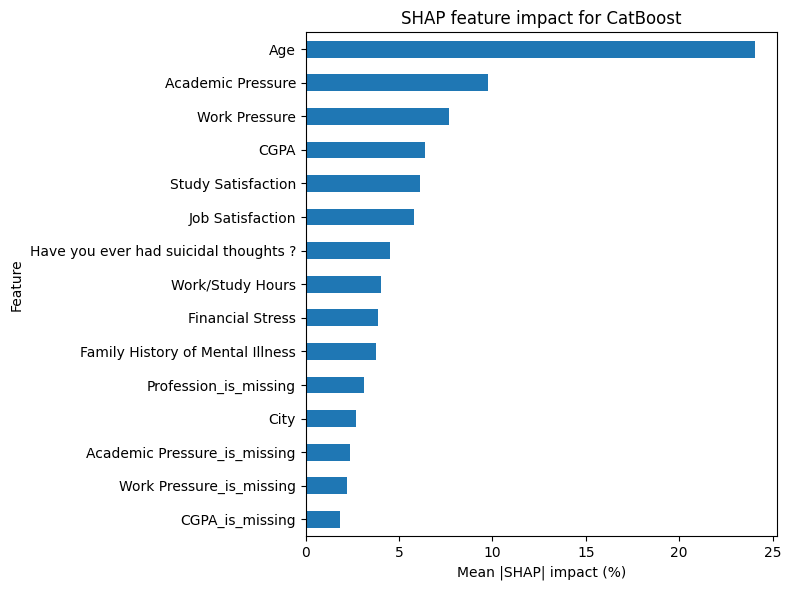

In [94]:
# SHAP: đo mức ảnh hưởng trung bình của từng feature tới prediction
import matplotlib.pyplot as plt
import shap

shap_sample_size = min(2000, len(X_val))
X_shap_raw = X_val.sample(n=shap_sample_size, random_state=RANDOM_STATE)

best_preprocessor = best_model.named_steps['preprocess']
best_classifier = best_model.named_steps['classifier']

X_shap_processed = best_preprocessor.transform(X_shap_raw)
feature_names = best_preprocessor.get_feature_names_out()

explainer = shap.TreeExplainer(best_classifier)
shap_values = explainer.shap_values(X_shap_processed)

if isinstance(shap_values, list):
    shap_values_for_class = shap_values[1] if len(shap_values) > 1 else shap_values[0]
else:
    shap_values_for_class = np.asarray(shap_values)
    if shap_values_for_class.ndim == 3:
        class_index = 1 if shap_values_for_class.shape[2] > 1 else 0
        shap_values_for_class = shap_values_for_class[:, :, class_index]

mean_abs_shap = np.abs(shap_values_for_class).mean(axis=0)
impact_percent = mean_abs_shap / mean_abs_shap.sum() * 100

shap_feature_importance = pd.DataFrame(
    {
        'feature': feature_names,
        'mean_abs_shap': mean_abs_shap,
        'mean_shap_value': shap_values_for_class.mean(axis=0),
        'impact_percent': impact_percent,
    }
).sort_values('impact_percent', ascending=False).reset_index(drop=True)

numeric_feature_names = list(best_preprocessor.transformers_[0][2])
categorical_feature_names = list(best_preprocessor.transformers_[1][2])
onehot_encoder = best_preprocessor.named_transformers_['cat'].named_steps['onehot']

original_feature_names = numeric_feature_names.copy()
for col, categories in zip(categorical_feature_names, onehot_encoder.categories_):
    original_feature_names.extend([col] * len(categories))

if len(original_feature_names) != len(feature_names):
    original_feature_names = feature_names

shap_original_feature_importance = (
    shap_feature_importance.assign(original_feature=original_feature_names)
    .groupby('original_feature', as_index=False)
    .agg(
        mean_abs_shap=('mean_abs_shap', 'sum'),
        mean_shap_value=('mean_shap_value', 'sum'),
        impact_percent=('impact_percent', 'sum'),
    )
    .sort_values('impact_percent', ascending=False)
    .reset_index(drop=True)
)

display(shap_original_feature_importance.head(20))
display(shap_feature_importance.head(20))

ax = shap_original_feature_importance.head(15).sort_values('impact_percent').plot.barh(
    x='original_feature',
    y='impact_percent',
    legend=False,
    figsize=(8, 6),
)
ax.set_xlabel('Mean |SHAP| impact (%)')
ax.set_ylabel('Feature')
ax.set_title(f'SHAP feature impact for {best_model_name}')
plt.tight_layout()
plt.show()

In [ ]:
# Tạo submission bằng Stratified K-Fold ensemble CatBoost + XGBoost
from sklearn.model_selection import StratifiedKFold

N_SPLITS = 5
PREDICTION_THRESHOLD = 0.5
ENSEMBLE_MODEL_NAMES = ['CatBoost', 'XGBoost']

missing_ensemble_models = [name for name in ENSEMBLE_MODEL_NAMES if name not in tree_models]
if missing_ensemble_models:
    raise ValueError(f'Missing ensemble models: {missing_ensemble_models}')

kfold = StratifiedKFold(
    n_splits=N_SPLITS,
    shuffle=True,
    random_state=RANDOM_STATE,
)

oof_proba_by_model = {
    name: np.zeros(len(X_clean))
    for name in ENSEMBLE_MODEL_NAMES
}
test_proba_by_model = {
    name: np.zeros(len(X_test_clean))
    for name in ENSEMBLE_MODEL_NAMES
}
fold_results = []
final_models = {name: [] for name in ENSEMBLE_MODEL_NAMES}

for fold, (train_idx, val_idx) in enumerate(kfold.split(X_clean, y), start=1):
    X_fold_train = X_clean.iloc[train_idx]
    X_fold_val = X_clean.iloc[val_idx]
    y_fold_train = y.iloc[train_idx]
    y_fold_val = y.iloc[val_idx]

    for model_name in ENSEMBLE_MODEL_NAMES:
        model = Pipeline(
            steps=[
                ('preprocess', clone(preprocessor)),
                ('classifier', clone(tree_models[model_name])),
            ]
        )

        model.fit(X_fold_train, y_fold_train)

        val_proba = model.predict_proba(X_fold_val)[:, 1]
        val_pred = (val_proba >= PREDICTION_THRESHOLD).astype(int)

        oof_proba_by_model[model_name][val_idx] = val_proba
        test_proba_by_model[model_name] += model.predict_proba(X_test_clean)[:, 1] / N_SPLITS
        final_models[model_name].append(model)

        fold_results.append(
            {
                'model': model_name,
                'fold': fold,
                'accuracy': accuracy_score(y_fold_val, val_pred),
                'precision': precision_score(y_fold_val, val_pred),
                'recall': recall_score(y_fold_val, val_pred),
                'f1': f1_score(y_fold_val, val_pred),
                'roc_auc': roc_auc_score(y_fold_val, val_proba),
            }
        )

fold_results_df = pd.DataFrame(fold_results)
display(fold_results_df)
display(fold_results_df.groupby('model').agg({
    'accuracy': ['mean', 'std'],
    'precision': ['mean', 'std'],
    'recall': ['mean', 'std'],
    'f1': ['mean', 'std'],
    'roc_auc': ['mean', 'std'],
}))

ensemble_weight_results = []
for catboost_weight in np.arange(0.0, 1.01, 0.05):
    xgboost_weight = 1.0 - catboost_weight
    ensemble_oof_proba = (
        catboost_weight * oof_proba_by_model['CatBoost']
        + xgboost_weight * oof_proba_by_model['XGBoost']
    )
    ensemble_oof_pred = (ensemble_oof_proba >= PREDICTION_THRESHOLD).astype(int)
    ensemble_weight_results.append(
        {
            'catboost_weight': catboost_weight,
            'xgboost_weight': xgboost_weight,
            'accuracy': accuracy_score(y, ensemble_oof_pred),
            'precision': precision_score(y, ensemble_oof_pred),
            'recall': recall_score(y, ensemble_oof_pred),
            'f1': f1_score(y, ensemble_oof_pred),
            'roc_auc': roc_auc_score(y, ensemble_oof_proba),
        }
    )

ensemble_weight_results_df = pd.DataFrame(ensemble_weight_results).sort_values(
    by=['accuracy', 'f1'],
    ascending=False,
).reset_index(drop=True)

display(ensemble_weight_results_df.head(10))

best_catboost_weight = ensemble_weight_results_df.loc[0, 'catboost_weight']
best_xgboost_weight = ensemble_weight_results_df.loc[0, 'xgboost_weight']

oof_proba = (
    best_catboost_weight * oof_proba_by_model['CatBoost']
    + best_xgboost_weight * oof_proba_by_model['XGBoost']
)
test_proba = (
    best_catboost_weight * test_proba_by_model['CatBoost']
    + best_xgboost_weight * test_proba_by_model['XGBoost']
)

submission = pd.DataFrame(
    {
        ID_COL: test_ids,
        TARGET_COL: (test_proba >= PREDICTION_THRESHOLD).astype(int),
    }
)
display(submission.head())

submission.to_csv('submission.csv', index=False)

print(f'Final submission model: CatBoost/XGBoost {N_SPLITS}-fold ensemble')
print('CatBoost weight:', best_catboost_weight)
print('XGBoost weight:', best_xgboost_weight)
print('Prediction threshold:', PREDICTION_THRESHOLD)
print('OOF ROC-AUC:', roc_auc_score(y, oof_proba))
print('OOF accuracy:', accuracy_score(y, (oof_proba >= PREDICTION_THRESHOLD).astype(int)))
print('OOF F1:', f1_score(y, (oof_proba >= PREDICTION_THRESHOLD).astype(int)))